In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score
from yellowbrick.cluster import KElbowVisualizer # You might need to install yellowbrick: pip install yellowbrick

# Load the dataset
df = pd.read_csv('Mall_Customers.csv')

# Display the first few rows to understand the data
print(df.head())
print(df.info())


   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB
None


Feature Choice Justification:



*   Annual Income (k$) and Spending Score (1-100): These  two features are the most relevant numerical features for spending behavior analysis. If we combine income levels with spending habits it will directly addresses the goal : to segmment shoppers by spending behavior.


*   Age: Age can be an influence on a customers shopping behavior and thier preferences. This can a valuable demographic feature to include in the segmentation.

* Gender: The gender also might reveal segemented spending behavior.











In [3]:
# Drop CustomerID, This is a unique identifier and provides no behavioral information
df = df.drop('CustomerID', axis=1)

# Handle Gender (Binary Encoding)
df['Gender'] = df['Gender'].apply(lambda x: 1 if x == 'Male' else 0) # 1 for Male, 0 for Female

# Checking for missing values
print(df.isnull().sum())

# Select features for clustering (including encoded Gender and Age for richer profiling)
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64


**Finding the Optimizal Number of Clusters(k)**

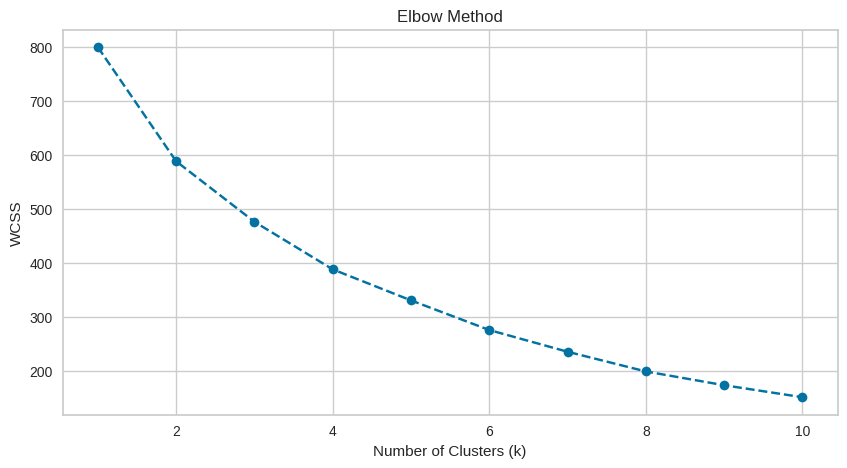

Silhouette Score for k=2: 0.2518
Silhouette Score for k=3: 0.2595
Silhouette Score for k=4: 0.2984
Silhouette Score for k=5: 0.3041
Silhouette Score for k=6: 0.3311
Silhouette Score for k=7: 0.3574
Silhouette Score for k=8: 0.3880
Silhouette Score for k=9: 0.4031
Silhouette Score for k=10: 0.4208


In [4]:
# Elbow Method to find optimal k
wcss = [] # Within-Cluster Sum of Squares

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Inertia is the WCSS

# Plot the Elbow Method results
plt.figure(figsize=(10, 5))
plt.plot(range(1, 11), wcss, marker='o', linestyle='--')
plt.title('Elbow Method')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# Silhouette Score for a range of k
silhouette_scores = []
for i in range(2, 11): # Silhouette score requires at least 2 clusters
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    score = silhouette_score(X_scaled, kmeans.labels_)
    silhouette_scores.append(score)
    print(f'Silhouette Score for k={i}: {score:.4f}')



**Silhouette Score:**

I am using the silhouette score metric to evalutate the quality of the clustering in the dataset.The variable k represents the number of clusters, and the goal is to find the optimal k for the dataset. To interpret these results we must understand that a score close to +1 is well matched and well seperated from other clusters. Where a score 0 suggestes overlapping / the data point is on the decision boundary between two cluster. Close to -1 score indiciated the data points are assigned to the wrong cluster.

If we exmain the silhouette scorse, we see the highest score at k = 10, this means that 10 is a good numver of clusters for this dataset based on this metric alone.

**Elbow plot:**

Based on the Elbow plot, the decrease in the Within-Cluster Sum of Squares (WCSS) significantly slows down after \(k=3\) or \(k=4\). This indicates that adding more clusters beyond this point provides diminishing returns in terms of reducing WCSS.

**Fit K-Means with the Chosen k and Cluster Profiling**

        Gender                                                Age             \
         count      mean       std  min  25%  50%  75%  max count       mean   
Cluster                                                                        
0         85.0  0.458824  0.501259  0.0  0.0  0.0  1.0  1.0  85.0  28.047059   
1         66.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  66.0  45.075758   
2         49.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0  49.0  49.204082   

         ... Annual Income (k$)        Spending Score (1-100)             \
         ...                75%    max                  count       mean   
Cluster  ...                                                               
0        ...               78.0  137.0                   85.0  72.882353   
1        ...               71.5  126.0                   66.0  36.181818   
2        ...               78.0  137.0                   49.0  29.734694   

                                                  
           

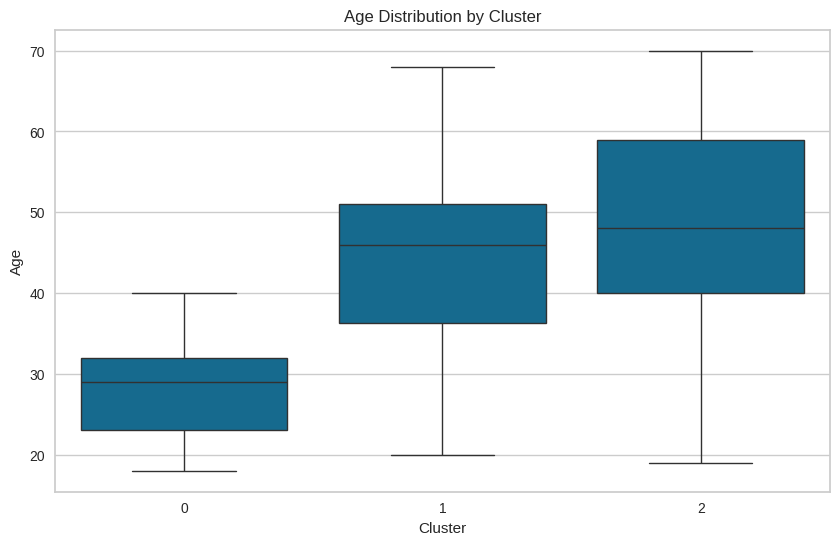

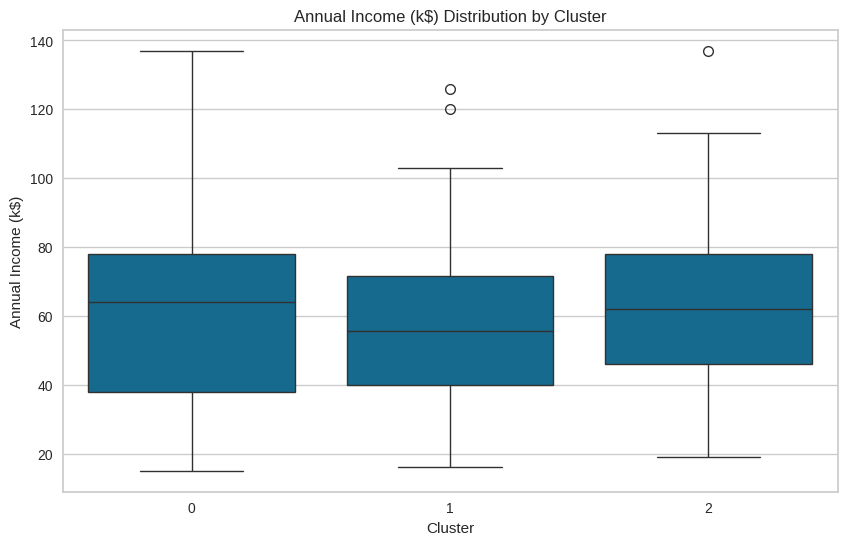

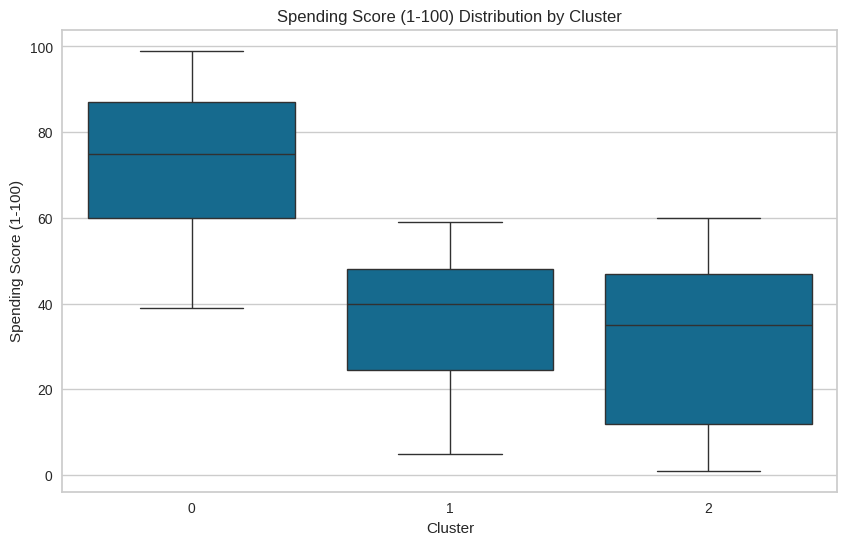

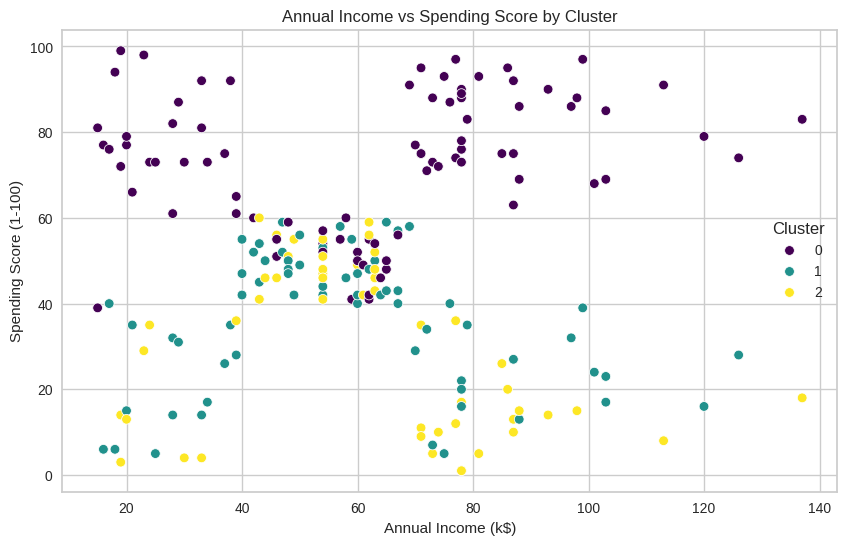

In [5]:

final_k = 3
kmeans = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Add original feature columns to the df for profiling
df_profile = df.copy()

# Perform Cluster Profiling
# Descriptive statistics summary
print(df_profile.groupby('Cluster').describe())

# Visualizations: Boxplots by cluster for key variables
for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=col, data=df_profile)
    plt.title(f'{col} Distribution by Cluster')
    plt.show()

# Visualizations: Pair plot of main variables colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_profile, palette='viridis')
plt.title('Annual Income vs Spending Score by Cluster')
plt.show()


Observation:

In examning the pair plot we can see the we need to potential re-run the Elbow method and Cluster profile needs to be redone.

1. The purple cluster (Cluster 0) is not a single group. It is split into three separate sections, meaning the model is incorrectly grouping very different customer profiles together.

2. There is significant intermingling between the green (Cluster 1) and yellow (Cluster 2) data points in the middle of the graph. This lack of clear separation indicates that the three-cluster model is not accurately segmenting the data.





In [18]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import pandas as pd


features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- Clustering Using KMeans ---

optimal_k = 4


kmeans = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++', n_init=10)

# Fit the model and predict the cluster labels for each data point
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Verify that the 'Cluster' column has been added
print(df.head())


   Gender  Age  Annual Income (k$)  Spending Score (1-100)  Cluster
0       1   19                  15                      39        1
1       1   21                  15                      81        1
2       0   20                  16                       6        0
3       0   23                  16                      77        2
4       0   31                  17                      40        0


In [9]:
# --- Clustering Profiling ---
# Compute the mean of each feature within each cluster
cluster_profiles = df.groupby('Cluster')[features].mean()

# Display the profiles
print("\nCluster Profiles (Mean values):")
print(cluster_profiles)



Cluster Profiles (Mean values):
         Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                               
0           0.0  47.803571           58.071429               34.875000
1           1.0  28.000000           62.239130               64.826087
2           0.0  28.392857           60.428571               68.178571
3           1.0  52.738095           62.214286               30.642857


Revealed from the clusters:

Cluster 0: Customers in this group have a mean age of 47.8 and an average annual income of $58,071. Their average spending score is relatively low at 34.88.

Cluster 1: This cluster has the youngest customers on average, with a mean age of 28. Their annual income is around $62,239, and they have a high average spending score of 64.83.

Cluster 2: The customers in this cluster are also relatively young, with a mean age of 28.4. Their average annual income is $60,428, and they have the highest average spending score at 68.18.

Cluster 3: This group has the oldest customers on average, with a mean age of 52.7. Their average annual income is similar to the other groups at $62,214, but their average spending score is the lowest at 30.64.

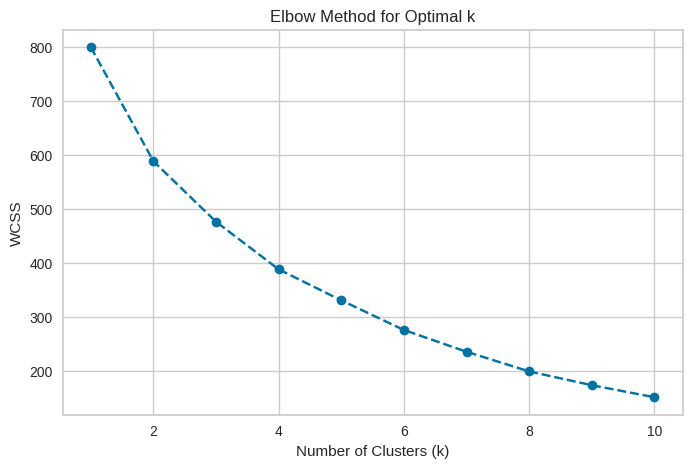


Cluster Profiles (Mean values):
         Gender        Age  Annual Income (k$)  Spending Score (1-100)
Cluster                                                               
0           0.0  47.803571           58.071429               34.875000
1           1.0  28.000000           62.239130               64.826087
2           0.0  28.392857           60.428571               68.178571
3           1.0  52.738095           62.214286               30.642857


In [12]:
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1. Prepare the Data ---
# Assuming your data is in a pandas DataFrame named 'df'
# and the features are as follows:
features = ['Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']
X = df[features]

# Scale the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


# --- 2. Finding Optimal Number of Clusters (Elbow Method) ---
# This is the code you provided, which is correct
wcss = [] # Within-Cluster Sum of Squares
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, init='k-means++', n_init=10)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_) # Inertia is the WCSS

# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(k_range, wcss, marker='o', linestyle='--')
plt.title('Elbow Method for Optimal k')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('WCSS')
plt.show()

# --- 3. Choose the Optimal k from the plot ---
# You need to manually look at the plot and decide where the 'elbow' is.
# Based on common results for this dataset, k=5 is a good choice.
optimal_k = 4

# --- 4. Clustering with the Optimal k ---
# This step was "skipped" in your initial notes.
kmeans = KMeans(n_clusters=optimal_k, random_state=42, init='k-means++', n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# --- 5. Clustering Profiling ---
# This allows you to understand the characteristics of each cluster.
cluster_profiles = df.groupby('Cluster')[features].mean()
print("\nCluster Profiles (Mean values):")
print(cluster_profiles)


        Gender                                      Age             ...  \
         count mean  std  min  25%  50%  75%  max count       mean  ...   
Cluster                                                             ...   
0         56.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  56.0  47.803571  ...   
1         46.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  46.0  28.000000  ...   
2         56.0  0.0  0.0  0.0  0.0  0.0  0.0  0.0  56.0  28.392857  ...   
3         42.0  1.0  0.0  1.0  1.0  1.0  1.0  1.0  42.0  52.738095  ...   

        Annual Income (k$)        Spending Score (1-100)             \
                       75%    max                  count       mean   
Cluster                                                               
0                    73.50  126.0                   56.0  34.875000   
1                    77.75  137.0                   46.0  64.826087   
2                    78.00  120.0                   56.0  68.178571   
3                    78.00  137.0               

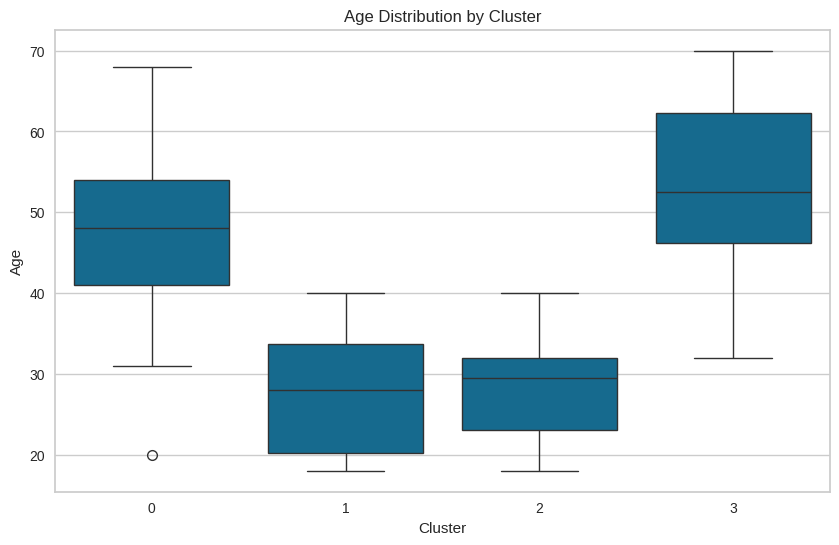

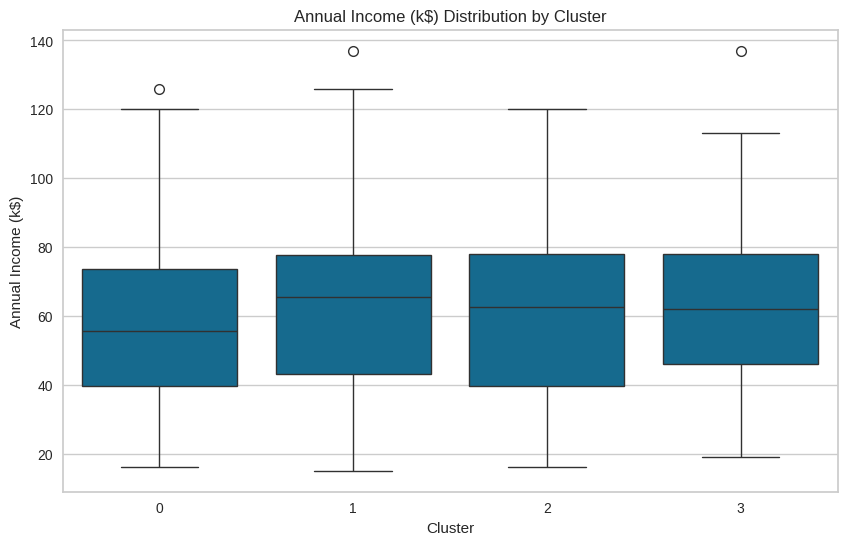

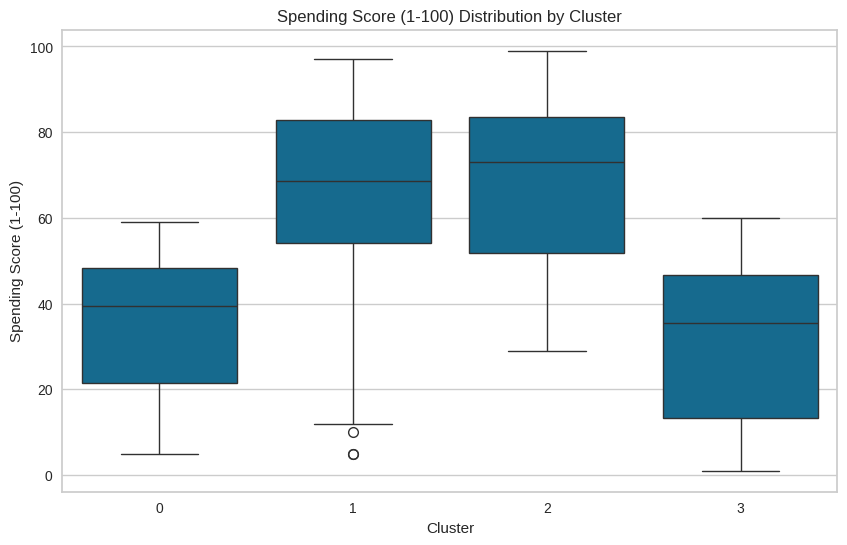

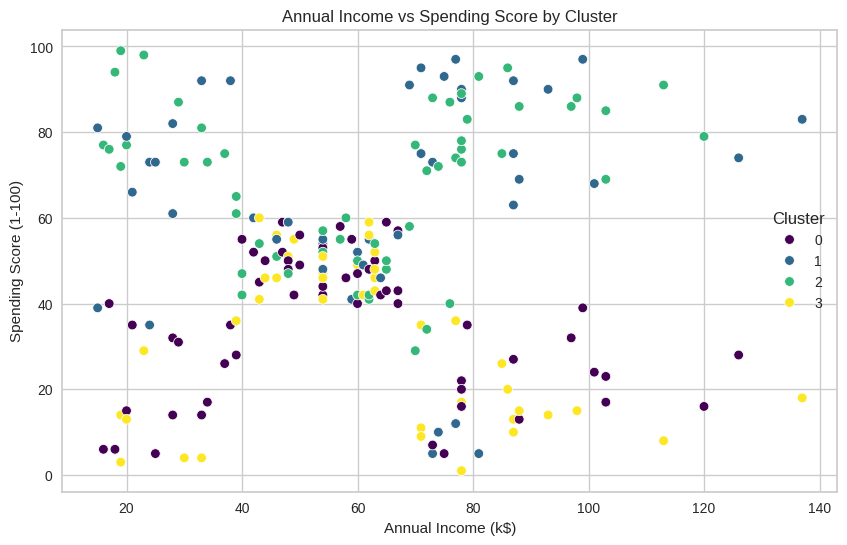

In [13]:
final_k = 4
kmeans = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Add original feature columns to the df for profiling
df_profile = df.copy()

# Perform Cluster Profiling
# Descriptive statistics summary
print(df_profile.groupby('Cluster').describe())

# Visualizations: Boxplots by cluster for key variables
for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=col, data=df_profile)
    plt.title(f'{col} Distribution by Cluster')
    plt.show()

# Visualizations: Pair plot of main variables colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_profile, palette='viridis')
plt.title('Annual Income vs Spending Score by Cluster')
plt.show()

        Gender                                                Age             \
         count      mean       std  min  25%  50%  75%  max count       mean   
Cluster                                                                        
0         39.0  0.461538  0.505035  0.0  0.0  0.0  1.0  1.0  39.0  32.692308   
1         29.0  0.448276  0.506120  0.0  0.0  0.0  1.0  1.0  29.0  36.482759   
2         43.0  0.000000  0.000000  0.0  0.0  0.0  0.0  0.0  43.0  49.813953   
3         54.0  0.407407  0.495966  0.0  0.0  0.0  1.0  1.0  54.0  24.907407   
4         35.0  1.000000  0.000000  1.0  1.0  1.0  1.0  1.0  35.0  55.714286   

         ... Annual Income (k$)        Spending Score (1-100)             \
         ...                75%    max                  count       mean   
Cluster  ...                                                               
0        ...              95.00  137.0                   39.0  82.128205   
1        ...              99.00  137.0                 

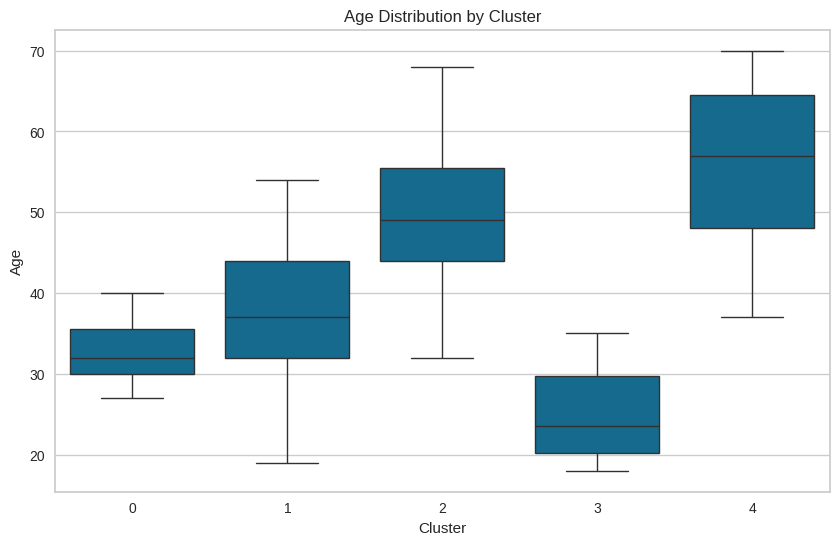

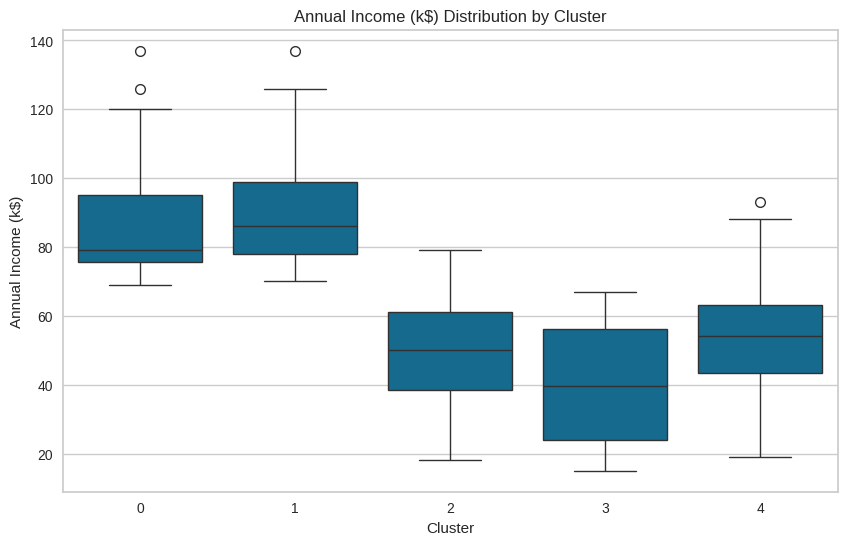

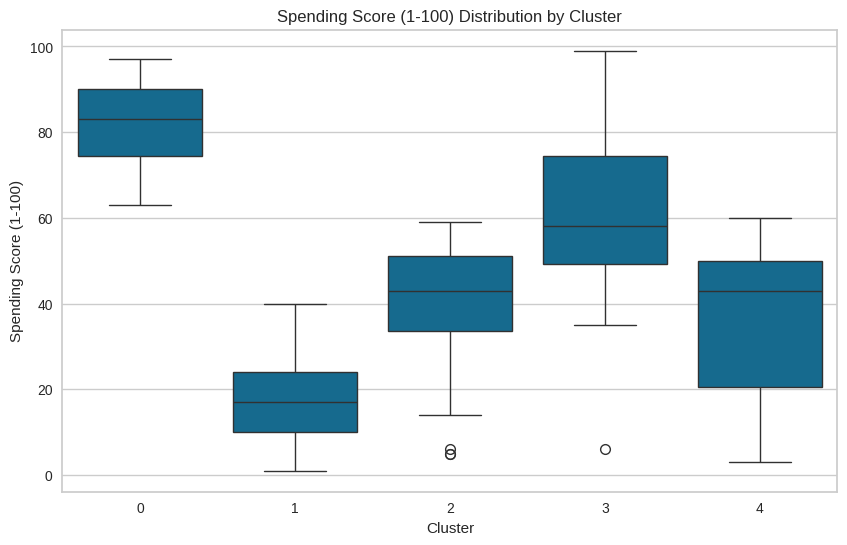

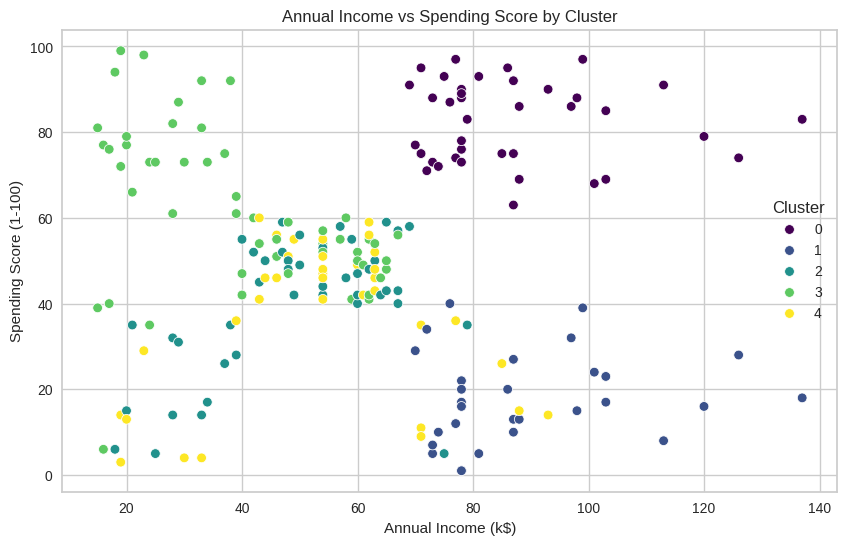

In [16]:
final_k = 5

kmeans = KMeans(n_clusters=final_k, init='k-means++', random_state=42, n_init=10)
df['Cluster'] = kmeans.fit_predict(X_scaled)

# Add original feature columns to the df for profiling
df_profile = df.copy()

# Perform Cluster Profiling
# Descriptive statistics summary
print(df_profile.groupby('Cluster').describe())

# Visualizations: Boxplots by cluster for key variables
for col in ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x='Cluster', y=col, data=df_profile)
    plt.title(f'{col} Distribution by Cluster')
    plt.show()

# Visualizations: Pair plot of main variables colored by cluster
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Annual Income (k$)', y='Spending Score (1-100)', hue='Cluster', data=df_profile, palette='viridis')
plt.title('Annual Income vs Spending Score by Cluster')
plt.show()

###  Cluster Summaries with Descriptive Statistics

#### **Cluster 0: High Income, High Spending**
- **Gender**: Mixed (mean ≈ 0.46)
- **Age**: Mean ≈ 32.7
- **Annual Income**: Mean ≈ 85.5k, Max = 137k
- **Spending Score**: Mean ≈ 82.1, Std ≈ 9.36
- **Profile**: Young, affluent, and high-spending consumers.

#### **Cluster 1: High Income, Low Spending**
- **Gender**: Mixed (mean ≈ 0.45)
- **Age**: Mean ≈ 36.5
- **Annual Income**: Mean ≈ 86.5k, Max = 137k
- **Spending Score**: Mean ≈ 18.0, Std ≈ 10.6
- **Profile**: Wealthy but conservative spenders.

#### **Cluster 2: Older, Moderate Income and Spending**
- **Gender**: All male (mean = 0.0)
- **Age**: Mean ≈ 49.8
- **Annual Income**: Mean ≈ 55.0k, Max = 79k
- **Spending Score**: Mean ≈ 40.1, Std ≈ 15.6
- **Profile**: Older males with moderate financial activity.

#### **Cluster 3: Young, Moderate Income, High Spending**
- **Gender**: Mixed (mean ≈ 0.41)
- **Age**: Mean ≈ 24.9
- **Annual Income**: Mean ≈ 56.0k, Max = 67k
- **Spending Score**: Mean ≈ 61.2, Std ≈ 18.4
- **Profile**: Young and enthusiastic spenders with moderate income.

#### **Cluster 4: Older, Female, Moderate Income and Spending**
- **Gender**: All female (mean = 1.0)
- **Age**: Mean ≈ 55.7
- **Annual Income**: Mean ≈ 58.0k, Max = 93k
- **Spending Score**: Mean ≈ 36.8, Std ≈ 15.6
- **Profile**: Older women with balanced spending habits.



###  Visualizations

#### 1. **Boxplot: Age Distribution by Cluster**
- Reveals clear age segmentation:
  - Cluster 3 is the youngest.
  - Cluster 4 is the oldest.
  - Cluster 2 and 4 show tight age ranges, suggesting demographic targeting.

#### 2. **Scatter Plot: Annual Income vs Spending Score by Cluster**
- Highlights behavioral contrasts:
  - Cluster 0: High income and high spending.
  - Cluster 1: High income but low spending.
  - Cluster 3: Lower income but high spending.
- Color-coded clusters show distinct groupings, useful for marketing segmentation.

---

###  Insights for Strategy
- **Cluster 0** is ideal for premium product targeting.
- **Cluster 1** may respond better to value-based promotions.
- **Cluster 3** could be influenced by lifestyle branding.
- **Cluster 2 and 4** suggest age-specific messaging and moderate pricing.



**Cluster Labels & Strategy Brief for Mall Marketing and Operations**

#### **Cluster 0: “- Elite Trendsetters ”**
- **Profile**: Young adults with high income and high spending scores.
- **Strategy**:
  - **Premium Loyalty Program**: Offer exclusive perks like early access to new collections or VIP lounge access.
  - **Luxury Layout Optimization**: Position high-end brands and tech-forward experiences near entrances or popular zones.
  - **Personalized Promotions**: Use app-based notifications for luxury product launches or curated shopping experiences.

---

#### **Cluster 1: “Wealth-Conscious Minimalists”**
- **Profile**: High income but low spending scores; moderate age.
- **Strategy**:
  - **Value-Based Campaigns**: Highlight quality and durability over trendiness—think “smart spending” messaging.
  - **Private Events**: Invite-only previews or educational workshops (e.g., investment fashion, sustainable goods).
  - **Discreet Incentives**: Subtle loyalty rewards like cashback or bundled savings without flashy marketing.

---

#### **Cluster 2: **Classic Value Seekers”**
- **Profile**: Older males with moderate income and spending.
- **Strategy**:
  - **Comfort-Oriented Layouts**: Seating areas, clear signage, and easy navigation to essentials.
  - **Practical Promotions**: Discounts on everyday wear, electronics, or home goods.
  - **Trust-Based Loyalty**: Emphasize reliability—long-term member benefits, consistent service.

---

#### **Cluster 3: “Young Spenders”**
- **Profile**: Young, moderate income, high spending scores.
- **Strategy**:
  - **Trend-Driven Promotions**: Flash sales, influencer tie-ins, and pop-up shops.
  - **Gamified Loyalty**: Points for social shares, app check-ins, or completing style challenges.
  - **Youth-Centric Zones**: Vibrant, interactive areas with music, tech, and fast fashion.

---

#### **Cluster 4: “Elegant Conservers”**
- **Profile**: Older females with moderate income and balanced spending.
- **Strategy**:
  - **Wellness & Lifestyle Focus**: Promote spa services, curated fashion, and health-conscious brands.
  - **Community Loyalty**: Invite to book clubs, wellness seminars, or seasonal showcases.
  - **Layout Adjustments**: Quiet zones, elegant displays, and personalized service counters.

